In [6]:
# Update files
import importlib
import config as cfg
import utils.io
import utils.metrics
import data.data_loader
import data.data_augmentation
import models.multi_layer_perceptron
import models.convolutional_neural_networks

importlib.reload(cfg)
importlib.reload(utils.io)
importlib.reload(utils.metrics)
importlib.reload(data.data_loader)
importlib.reload(data.data_augmentation)
importlib.reload(models.multi_layer_perceptron)
importlib.reload(models.convolutional_neural_networks)

# Import libraries  
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split

# Import functions
## Data
from data.data_loader import ButterflyDataset
from data.data_augmentation import apply_data_augmentation
from utils.io import print_images
from utils.metrics import analyze_df


## Utils
from utils.io import save_acc_graph
## Metric
from utils.metrics import evaluate_network

## MLP
from models.multi_layer_perceptron import MLP, fit

## CNN
from models.convolutional_neural_networks import CNN, fit

# Choose device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():    
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [8]:
# load the data
df = pd.read_csv(cfg.TRAIN_LABELS_PATH)

df_train, df_val = train_test_split(df, test_size=cfg.TEST_SIZE, random_state=42, stratify=df['label'])

workers = min(4, os.cpu_count() or 1)

if cfg.AUGMENT_DATA:
    train_transform, val_transform, sampler = apply_data_augmentation(df_train)

    # preprocessing (Datasets utilizam transforms independentes)
    train_dataset = ButterflyDataset(df=df_train, img_dir=cfg.TRAIN_IMG_DIR, transform=train_transform)
    val_dataset = ButterflyDataset(df=df_val, img_dir=cfg.TRAIN_IMG_DIR, transform=val_transform)
    
    train_loader = data.DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, sampler=sampler, num_workers=workers)
    val_loader = data.DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=workers)
else:
    # preprocessing (Não aplica-se data augmentation)
    data_transform = transforms.Compose([
        transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
        transforms.ToTensor()

    ])
    
    train_dataset = ButterflyDataset(df=df_train, img_dir=cfg.TRAIN_IMG_DIR, transform=data_transform)
    val_dataset = ButterflyDataset(df=df_val, img_dir=cfg.TRAIN_IMG_DIR, transform=data_transform)

    train_loader = data.DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=workers)
    val_loader = data.DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=workers)

print("✅ All images processed with SOTA Data Augmentation and Class Balancing...")

✅ All images processed with SOTA Data Augmentation and Class Balancing...


#### TRAIN DATASET ####
------------------------------
Número de classes: 75
Número de inputs para o MLP: 12288
------------------------------
------------------------------
                          Quantidade de Imagens  Proporção (%)
label                                                         
MOURNING CLOAK                               84       2.019716
SLEEPY ORANGE                                68       1.635008
ATALA                                        64       1.538831
BROWN SIPROETA                               63       1.514787
BANDED ORANGE HELICONIAN                     62       1.490743
...                                         ...            ...
AMERICAN SNOOT                               47       1.130079
GOLD BANDED                                  46       1.106035
WOOD SATYR                                   46       1.106035
CRIMSON PATCH                                46       1.106035
MALACHITE                                    46       1.106035

[75 ro

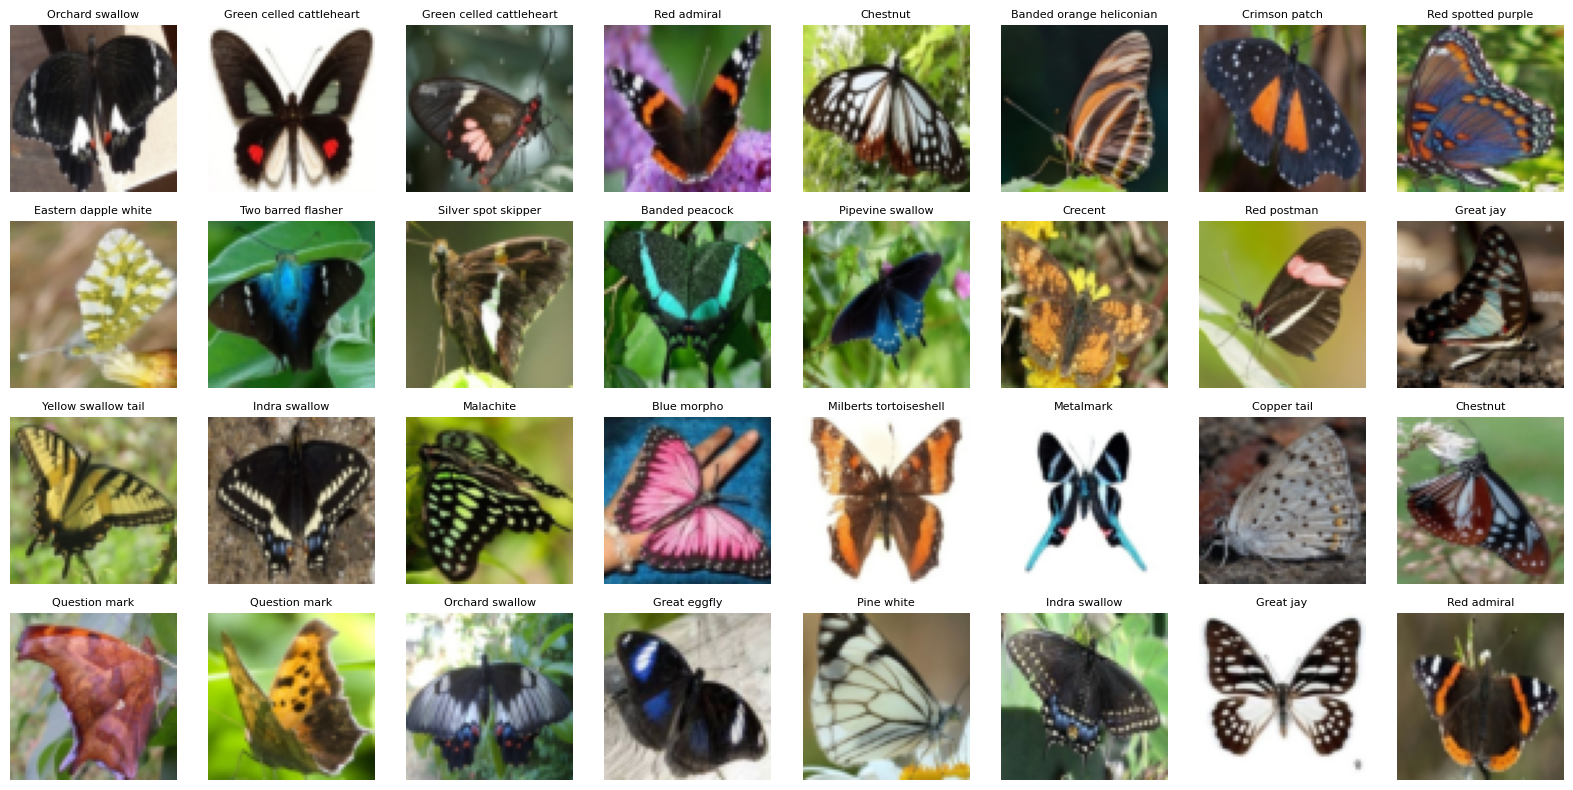

In [9]:
# Train data set analyze
print("#### TRAIN DATASET ####")
num_inputs, num_classes = analyze_df(df_train, train_dataset)
print_images(train_dataset, train_loader)

MLP

In [10]:
dnn = MLP(input_size=num_inputs, hidden_sizes=cfg.MLP_HIDDEN_LAYER_SIZES, num_classes=num_classes)

# Escolher Loss Function
if cfg.MLP_LOSS_FUNCTION == "CrossEntropy":
    criterion = nn.CrossEntropyLoss()
elif cfg.MLP_LOSS_FUNCTION == "CrossEntropy_LabelSmoothing":
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.MLP_LABEL_SMOOTHING) 
elif cfg.MLP_LOSS_FUNCTION == "MultiMarginLoss":
    criterion = nn.MultiMarginLoss()
else:
    raise ValueError(f"Loss Function desconhecida no config: {cfg.MLP_LOSS_FUNCTION}")

# Escolher Otimizador
if cfg.MLP_OPTIM == "RMSprop":
    optimizer = optim.RMSprop(dnn.parameters(), lr=cfg.MLP_LR)
elif cfg.MLP_OPTIM == "ADAM":
    optimizer = optim.Adam(dnn.parameters(), lr=cfg.MLP_LR)
elif cfg.MLP_OPTIM == "ADAMW":
    optimizer = optim.AdamW(dnn.parameters(), lr=cfg.MLP_LR, weight_decay=cfg.MLP_WEIGHT_DECAY)
elif cfg.MLP_OPTIM == "SGD":
    optimizer = optim.SGD(dnn.parameters(), lr=cfg.MLP_LR, momentum=cfg.MLP_MOMENTUM)
else:
    raise ValueError(f"Otimizador desconhecido no config: {cfg.MLP_OPTIM}")

# Treino
print(f"A iniciar o treino com {cfg.MLP_OPTIM} e {cfg.MLP_LOSS_FUNCTION}...")
mlp_train_acc, mlp_val_acc, dnn = fit(
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    nn=dnn,
    criterion=criterion, 
    optimizer=optimizer, 
    n_epochs=cfg.MLP_EPOCHS, 
    to_device=False
)

A iniciar o treino com ADAM e CrossEntropy...
Epoch [1/1], Train Acc: 0.0361 | Val Acc: 0.0798


In [5]:
if cfg.AUGMENT_DATA:
    mlp_result_file_path = cfg.mlp_results_path_augmented
else:
    mlp_result_file_path = cfg.mlp_results_path

print('Saving graphics showing acc results...')
save_acc_graph(mlp_train_acc, mlp_val_acc, mlp_result_file_path, cfg.mlp_results_folder_name, "RNN")

print('Evaluating with the training data...')
evaluate_network(
    net=dnn, 
    dataloader=train_loader, 
    device="cpu",
    save_path=mlp_result_file_path, 
    split_name="Treino"
)

print('Evaluating with the valid data...')
evaluate_network(
    net=dnn, 
    dataloader=val_loader, 
    device="cpu", 
    save_path=mlp_result_file_path,
    split_name="Validacao"
)

Saving graphics showing acc results...
Gráfico guardado com sucesso...
Evaluating with the training data...
[Treino] F1 Score: 0.0220
Métricas de Treino salvas...
Evaluating with the valid data...
[Validacao] F1 Score: 0.0226
Métricas de Validacao salvas...


(0.022630188056894738,
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(75, 75)))

CNN

In [ ]:
cnn = CNN(input_channels=3, num_classes=num_classes)

# Escolher Loss Function
if cfg.CNN_LOSS_FUNCTION == "CrossEntropy":
    criterion = nn.CrossEntropyLoss()
elif cfg.CNN_LOSS_FUNCTION == "CrossEntropy_LabelSmoothing":
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.CNN_LABEL_SMOOTHING) 
elif cfg.CNN_LOSS_FUNCTION == "MultiMarginLoss":
    criterion = nn.MultiMarginLoss()
else:
    raise ValueError(f"Loss Function desconhecida no config: {cfg.CNN_LOSS_FUNCTION}")

# Escolher Otimizador
if cfg.CNN_OPTIM == "RMSprop":
    optimizer = optim.RMSprop(cnn.parameters(), lr=cfg.CNN_LR)
elif cfg.CNN_OPTIM == "ADAM":
    optimizer = optim.Adam(cnn.parameters(), lr=cfg.CNN_LR)
elif cfg.CNN_OPTIM == "ADAMW":
    optimizer = optim.AdamW(cnn.parameters(), lr=cfg.CNN_LR, weight_decay=cfg.CNN_WEIGHT_DECAY)
elif cfg.CNN_OPTIM == "SGD":
    optimizer = optim.SGD(cnn.parameters(), lr=cfg.CNN_LR, momentum=cfg.CNN_MOMENTUM)
else:
    raise ValueError(f"Otimizador desconhecido no config: {cfg.CNN_OPTIM}")

# Treino
print(f"\nA iniciar o treino da CNN com {cfg.CNN_OPTIM} e {cfg.CNN_LOSS_FUNCTION}...")
cnn_train_acc, cnn_val_acc, cnn = fit(
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    nn=cnn,
    criterion=criterion, 
    optimizer=optimizer, 
    n_epochs=cfg.CNN_EPOCHS, 
    to_device=False,
    device=device
)


A iniciar o treino da CNN com ADAM e CrossEntropy...
Epoch [1/50], Train Acc: 0.0305 | Val Acc: 0.0740
Epoch [2/50], Train Acc: 0.0869 | Val Acc: 0.1875
Epoch [3/50], Train Acc: 0.1444 | Val Acc: 0.2452
Epoch [4/50], Train Acc: 0.1953 | Val Acc: 0.2952
Epoch [5/50], Train Acc: 0.2458 | Val Acc: 0.3346
Epoch [6/50], Train Acc: 0.2736 | Val Acc: 0.3962
Epoch [7/50], Train Acc: 0.3035 | Val Acc: 0.4183
Epoch [8/50], Train Acc: 0.3396 | Val Acc: 0.4673
Epoch [9/50], Train Acc: 0.3513 | Val Acc: 0.4769
Epoch [10/50], Train Acc: 0.3960 | Val Acc: 0.4981
Epoch [11/50], Train Acc: 0.3955 | Val Acc: 0.5067
Epoch [12/50], Train Acc: 0.4255 | Val Acc: 0.5202
Epoch [13/50], Train Acc: 0.4249 | Val Acc: 0.5413
Epoch [14/50], Train Acc: 0.4396 | Val Acc: 0.5519
Epoch [15/50], Train Acc: 0.4562 | Val Acc: 0.5615
Epoch [16/50], Train Acc: 0.4807 | Val Acc: 0.5683
Epoch [17/50], Train Acc: 0.4867 | Val Acc: 0.5712
Epoch [18/50], Train Acc: 0.4795 | Val Acc: 0.5779
Epoch [19/50], Train Acc: 0.5044 | Va

In [ ]:
if cfg.AUGMENT_DATA:
    cnn_result_file_path = cfg.cnn_results_path_augmented
else:
    cnn_result_file_path = cfg.cnn_results_path

print('Saving graphics showing acc results...')
save_acc_graph(cnn_train_acc, cnn_val_acc, cnn_result_file_path, cfg.cnn_results_folder_name, "CNN")

print('Evaluating with the training data...')
evaluate_network(
    net=cnn, 
    dataloader=train_loader, 
    device="cpu",
    save_path=cnn_result_file_path, 
    split_name="Treino",
)

print('Evaluating with the valid data...')
evaluate_network(
    net=cnn, 
    dataloader=val_loader, 
    device="cpu", 
    save_path=cnn_result_file_path, 
    split_name="Validacao",
)

Saving graphics showing loss results...
Gráfico guardado com sucesso...
Evaluating with the training data...
[Treino] F1 Score: 0.7905
Métricas de Treino salvas...
Evaluating with the valid data...
[Validacao] F1 Score: 0.6500
Métricas de Validacao salvas...


(0.6500359010714278,
 array([[11,  0,  0, ...,  1,  0,  0],
        [ 0,  7,  0, ...,  0,  0,  0],
        [ 0,  0,  7, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ...,  6,  0,  0],
        [ 0,  0,  0, ...,  0,  7,  0],
        [ 0,  0,  0, ...,  0,  0, 10]], shape=(75, 75)))